# Étape 12 — Synthèse finale, comparaison et recommandations

Ce notebook rassemble uniquement les résultats validés des Étapes 1 à 11. Il ne développe ni ne
réentraîne aucun modèle. Chaque conclusion est reliée à un artefact sauvegardé ; les résultats
original/enrichi et observed/predicted restent explicitement séparés.

## 1. Sources et tableau de bord

La question est : « le pipeline complet répond-il aux objectifs du cahier des charges ? » Nous
chargeons les summaries et principaux CSV plutôt que de recalculer les expériences. Le tableau de
bord montre les chiffres obtenus ; il ne permet pas à lui seul d'établir une causalité ou une
généralisation au recrutement réel.

In [1]:
from pathlib import Path
import json,pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display,Markdown

ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
RESULTS=ROOT/'results'; DATA=ROOT/'data'/'processed'; FIGURES=ROOT/'figures'/'step12'
FIGURES.mkdir(parents=True,exist_ok=True)
def load_json(name): return json.loads((RESULTS/name).read_text(encoding='utf-8'))

audit1=load_json('step1_dataset_audit.json'); graph2=load_json('step2_graph_summary.json')
struct3=load_json('step3_structural_summary.json'); comm4=load_json('step4_community_summary.json')
skill5=load_json('step5_skill_graph_summary.json'); split6=load_json('step6_link_split_summary.json')
semantic7=load_json('step7_semantic_link_prediction_summary.json'); classical8=load_json('step8_classical_link_prediction_summary.json')
compare9=load_json('step9_link_prediction_comparison_summary.json'); features10=load_json('step10_node_features_summary.json')
class11=load_json('step11_node_classification_summary.json')
method_comparison=pd.read_csv(RESULTS/'step9_method_comparison.csv')
ranking_test=pd.read_csv(RESULTS/'step9_ranking_test.csv')
classification_results=pd.read_csv(RESULTS/'step11_classification_results.csv')
best_models=pd.read_csv(RESULTS/'step11_best_models.csv')

dashboard=pd.DataFrame([
 ['Dataset','10 000 CV, 2 500 Jobs, 75 000 matches'],['Graphe biparti','12 500 nœuds, 75 000 arêtes'],
 ['Structure',f"densité={struct3['bipartite_density']}, composantes={struct3['n_connected_components']}, isolés={struct3['n_isolates']}"],
 ['Communautés globales',f"{comm4['n_communities']} communautés, Q={comm4['modularity_networkx']:.4f}"],
 ['Skill graph',f"{skill5['n_skill_nodes']} skills, {skill5['n_skill_communities']} communautés, Qw={skill5['selected_weighted_modularity']:.4f}"],
 ['Split link prediction','60 000 train / 7 500 val / 7 500 test positifs'],
 ['Prédiction sémantique',f"AUC test={semantic7['test_roc_auc']:.4f}"],
 ['Prédiction classique',f"Katz L=5 AUC test={classical8['continuous_metrics']['Katz tronqué L=5']['test_roc_auc']:.4f}"],
 ['Enrichissement',f"+{compare9['n_predicted_edges_added']} liens prédits, {compare9['n_edges_after']} arêtes finales"],
 ['Node features','14 features CV, 7 Job + embeddings 384D'],
 ['Classification','5 tâches locales + 3 propagations relationnelles globales'],
],columns=['Étape','Résultat clé'])
display(dashboard)

,Étape,Résultat clé
0,Dataset,"10 000 CV, 2 500 Jobs, 75 000 matches"
1,Graphe biparti,"12 500 nœuds, 75 000 arêtes"
2,Structure,"densité=0.003, composantes=36, isolés=29"
3,Communautés globales,"37 communautés, Q=0.8725"
4,Skill graph,"73 skills, 8 communautés, Qw=0.7184"
5,Split link prediction,60 000 train / 7 500 val / 7 500 test positifs
6,Prédiction sémantique,AUC test=0.8676
7,Prédiction classique,Katz L=5 AUC test=0.9445
8,Enrichissement,"+5347 liens prédits, 80347 arêtes finales"
9,Node features,"14 features CV, 7 Job + embeddings 384D"


## 2. Structure originale et changement après enrichissement

Le graphe original est la vérité observée : sparse, biparti, avec des Jobs de degré artificiellement
constant. Le graphe enrichi est un scénario de recommandations, pas une nouvelle ground truth. Nous
présentons uniquement les changements essentiels, sans répéter Step 3.

In [2]:
structural_final=pd.DataFrame([
 ['Original',75_000,0.003,7.5,30.0,36,29],
 ['Enrichi',compare9['n_edges_after'],compare9['density_before_after']['after'],
  compare9['degree_statistics_before_after']['after']['average_degree_cv'],
  compare9['degree_statistics_before_after']['after']['average_degree_job'],
  compare9['n_components_before_after']['after'],compare9['n_isolates_before_after']['after']]
],columns=['graph','edges','bipartite_density','avg_degree_cv','avg_degree_job','components','isolates'])
display(structural_final)

,graph,edges,bipartite_density,avg_degree_cv,avg_degree_job,components,isolates
0,Original,75000,0.003000,7.5000,30.0000,36,29
1,Enrichi,80347,0.003214,8.0347,32.1388,36,29


## 3. Communautés globales et internes

Les communautés globales regroupent CV et Jobs ; les huit grands blocs validés sont dominés par des
familles de rôles (Software, Finance, Product, etc.). Le skill graph apprend huit familles sur 73
compétences. ARI/NMI comparent les partitions original/enrichi indépendamment de leurs numéros :
ils indiquent une stabilité, pas une causalité des nouvelles arêtes.

In [3]:
profiles4=load_json('step4_community_profiles.json')
community_blocks=[]
for p in profiles4:
    community_blocks.append({'community_id':p['community_id'],'size':p['size'],
      'dominant_roles':', '.join(x['value'] for x in p['top_roles_cv'][:3]),
      'dominant_skills':', '.join(x['value'] for x in p['top_resume_skills'][:3])})
display(pd.DataFrame(community_blocks))
community_overview=pd.Series({'original_communities':comm4['n_communities'],'original_modularity':comm4['modularity_networkx'],
 'enriched_communities':features10['enriched_community_count'],'enriched_modularity':features10['enriched_modularity'],
 'ARI':features10['community_ARI'],'NMI':features10['community_NMI'],
 'skill_nodes':skill5['n_skill_nodes'],'skill_communities':skill5['n_skill_communities'],
 'weighted_skill_modularity':skill5['selected_weighted_modularity'],'mean_cv_skill_communities':skill5['cv_internal_feature_statistics']['n_skill_communities']['mean'],
 'mean_skill_entropy':skill5['cv_internal_feature_statistics']['skill_community_entropy']['mean']})
display(community_overview.to_frame('value'))

,community_id,size,dominant_roles,dominant_skills
0,0,1628,"Backend Engineer, Software Engineer, Full Stac...","JavaScript, Python, OOP"
1,1,1571,"Financial Analyst, FP&A Analyst, Junior Accoun...","Reporting, Financial Modeling, Forecasting"
2,2,1565,"Product Manager, Associate Product Manager, Te...","Prioritization, Agile, Product Strategy"
3,3,1562,"BI Analyst, Business Analyst, Data Analyst","Tableau, Power BI, Python"
4,4,1559,"Sales Representative, Business Development Man...","Forecasting, Prospecting, CRM"
5,5,1550,"Marketing Manager, Content Marketer, Performan...","Content Marketing, A/B Testing, Landing Pages"
6,6,1531,"Operations Manager, Project Manager, Program C...","Process Improvement, Reporting, Timeline Manag..."
7,7,1505,"Technical Support Specialist, Customer Support...","Root Cause Analysis, Intercom, Communication"


,value
original_communities,37.000000
original_modularity,0.872458
enriched_communities,37.000000
enriched_modularity,0.872558
ARI,0.999636
NMI,0.999364
skill_nodes,73.000000
skill_communities,8.000000
weighted_skill_modularity,0.718392
mean_cv_skill_communities,1.515400


## 4. Tableau final de link prediction

ROC-AUC mesure le classement sur le benchmark équilibré ; AP résume précision-rappel et F1 dépend
du seuil choisi sur validation. Les adaptations CN3/Adamic–Adar sont bipartites et Katz est tronqué
à L=5. Ces métriques permettent une comparaison contrôlée, mais pas d'estimer directement la
précision parmi 10 000 candidats.

,method,roc_auc,average_precision,f1
9,Katz tronqué L=5,0.944535,0.903252,0.944031
8,Adamic-Adar bipartite adapté,0.896257,0.861063,0.892943
7,CN3 bipartite adapté,0.895914,0.859160,0.892943
5,Semantic cosine,0.867627,0.840386,0.816180
6,Preferential Attachment,0.525303,0.519150,0.667141


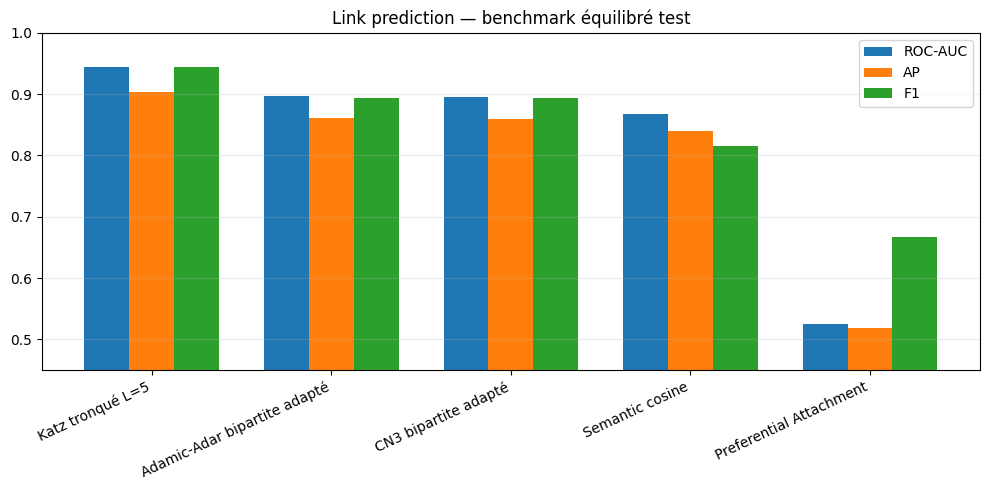

In [4]:
lp_test=method_comparison[method_comparison.split=='test'][['method','roc_auc','average_precision','f1']].sort_values('roc_auc',ascending=False)
display(lp_test)
fig,ax=plt.subplots(figsize=(10,5)); x=np.arange(len(lp_test)); w=.25
for i,(col,label) in enumerate([('roc_auc','ROC-AUC'),('average_precision','AP'),('f1','F1')]): ax.bar(x+(i-1)*w,lp_test[col],w,label=label)
ax.set_xticks(x,lp_test.method,rotation=25,ha='right'); ax.set_ylim(.45,1); ax.set_title('Link prediction — benchmark équilibré test'); ax.legend(); ax.grid(axis='y',alpha=.25)
fig.tight_layout(); fig.savefig(FIGURES/'link_prediction_comparison.png',dpi=170,bbox_inches='tight'); plt.show()

## 5. Benchmark équilibré contre ranking réaliste

Une bonne AUC sur 50 % de positifs ne signifie pas qu'un vrai match arrive facilement dans un Top-K
parmi presque 10 000 CV. Le base-rate naturel est proche de 0,3 %. Precision@K et Recall@K répondent
à cette seconde question. Cette différence constitue un résultat méthodologique majeur du projet.

,method,metric,value
0,Semantic,Balanced ROC-AUC,0.867627
1,Semantic,Balanced AP,0.840386
2,Semantic,Precision@50,0.002838
3,Semantic,Recall@50,0.043626
4,Katz,Balanced ROC-AUC,0.944535
5,Katz,Balanced AP,0.903252
6,Katz,Precision@50,0.003254
7,Katz,Recall@50,0.049923


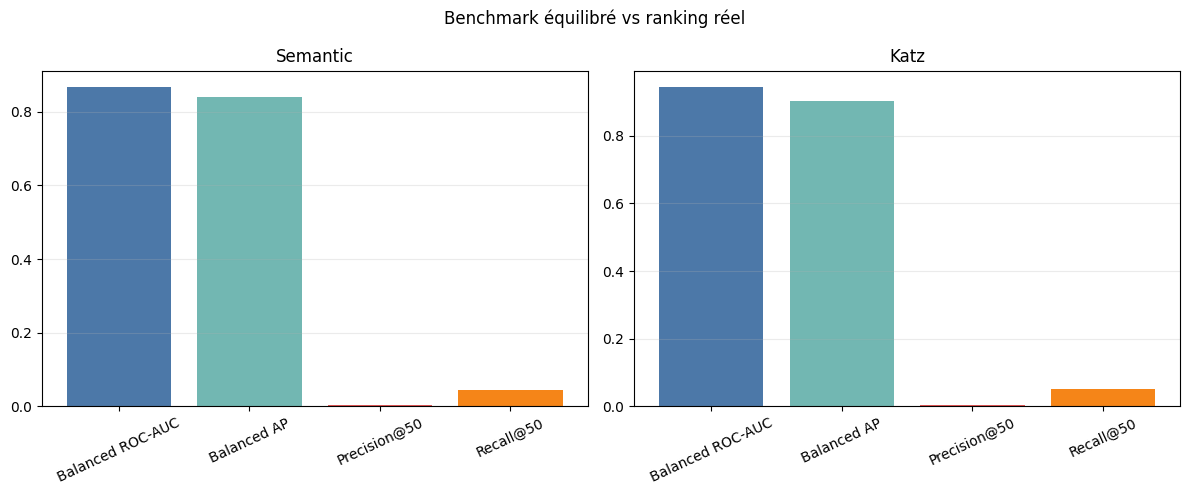

In [5]:
selected_k=compare9['selected_consensus_k']
balanced_vs_ranking=pd.DataFrame([
 ['Semantic','Balanced ROC-AUC',semantic7['test_roc_auc']],['Semantic','Balanced AP',semantic7['test_average_precision']],
 ['Semantic',f'Precision@{selected_k}',compare9['semantic_test_ranking_metrics']['precision_at_k']],
 ['Semantic',f'Recall@{selected_k}',compare9['semantic_test_ranking_metrics']['recall_at_k']],
 ['Katz','Balanced ROC-AUC',classical8['continuous_metrics']['Katz tronqué L=5']['test_roc_auc']],
 ['Katz','Balanced AP',classical8['continuous_metrics']['Katz tronqué L=5']['test_average_precision']],
 ['Katz',f'Precision@{selected_k}',compare9['katz_test_ranking_metrics']['precision_at_k']],
 ['Katz',f'Recall@{selected_k}',compare9['katz_test_ranking_metrics']['recall_at_k']],
],columns=['method','metric','value'])
display(balanced_vs_ranking)
fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,method in zip(axes,['Semantic','Katz']):
    p=balanced_vs_ranking[balanced_vs_ranking.method==method]; ax.bar(p.metric,p.value,color=['#4C78A8','#72B7B2','#E45756','#F58518']); ax.set_title(method); ax.tick_params(axis='x',rotation=25); ax.grid(axis='y',alpha=.25)
fig.suptitle('Benchmark équilibré vs ranking réel'); fig.tight_layout(); fig.savefig(FIGURES/'balanced_vs_ranking.png',dpi=170,bbox_inches='tight'); plt.show()

## 6. Enrichissement prudent

Le consensus Top-50 Semantic∩Katz ajoute uniquement des non-arêtes du graphe complet. Sa précision
ranking test absolue reste `0,00358`; les 5 347 liens sont donc des suggestions expérimentales avec
métadonnées, jamais des matches confirmés.

In [6]:
enrichment_summary=pd.Series({'observed_edges_before':compare9['n_observed_edges_before'],'predicted_edges_added':compare9['n_predicted_edges_added'],
 'edges_after':compare9['n_edges_after'],'density_before':compare9['density_before_after']['before'],'density_after':compare9['density_before_after']['after'],
 'consensus_test_precision':compare9['consensus_test_metrics']['consensus_precision'],'consensus_test_recall':compare9['consensus_test_metrics']['consensus_recall'],
 'components_before':compare9['n_components_before_after']['before'],'components_after':compare9['n_components_before_after']['after'],
 'isolates_before':compare9['n_isolates_before_after']['before'],'isolates_after':compare9['n_isolates_before_after']['after']})
display(enrichment_summary.to_frame('value'))

,value
observed_edges_before,75000.000000
predicted_edges_added,5347.000000
edges_after,80347.000000
density_before,0.003000
density_after,0.003214
consensus_test_precision,0.003583
consensus_test_recall,0.002400
components_before,36.000000
components_after,36.000000
isolates_before,29.000000


## 7. Classification finale et familles de features

Les modèles ont été sélectionnés uniquement sur validation. Les lignes ci-dessous sont les
configurations principales, excluant l'enrichi comme référence. Pour analyser les familles, nous
comparons les évaluations test déjà gelées ; une valeur test plus élevée n'autorise pas à modifier
la sélection a posteriori.

In [7]:
display(best_models)
local_test=classification_results[(classification_results.split=='test') & (classification_results.method!='Relational probabilistic classifier')]
family_table=local_test[['task','feature_family','graph_version','method','accuracy','balanced_accuracy','macro_f1']].sort_values(['task','macro_f1'],ascending=[True,False])
display(family_table)
rel_test=classification_results[(classification_results.split=='test') & (classification_results.method=='Relational probabilistic classifier')]
display(rel_test[['task','graph_version','accuracy','balanced_accuracy','macro_f1']])

,task,method,feature_family,graph_version,validation_macro_f1,validation_balanced_accuracy,test_macro_f1,test_accuracy,test_balanced_accuracy
0,CV seniority,Logistic Regression,SEMANTIC,invariant,0.868113,0.868643,0.876903,0.877333,0.877674
1,CV specialization proxy,Logistic Regression,STRUCTURAL,original,0.939382,0.960039,0.939326,0.945333,0.959471
2,Job seniority,Random Forest,STRUCTURAL,original,0.355358,0.356841,0.298912,0.298667,0.299323
3,Job industry,Logistic Regression,SEMANTIC,invariant,1.000000,1.000000,1.000000,1.000000,1.000000
4,Job specialization proxy,Logistic Regression,STRUCTURAL,original,0.835985,0.903571,0.898153,0.914667,0.942652


,task,feature_family,graph_version,method,accuracy,balanced_accuracy,macro_f1
19,CV seniority,ALL_SAFE,original,Logistic Regression,0.880667,0.880992,0.880152
23,CV seniority,ALL_SAFE,enriched,Logistic Regression,0.880667,0.880992,0.880152
11,CV seniority,SEMANTIC,invariant,Logistic Regression,0.877333,0.877674,0.876903
3,CV seniority,STRUCTURAL,original,Random Forest,0.347333,0.347310,0.347191
15,CV seniority,INTERNAL_SKILLS,invariant,Logistic Regression,0.316000,0.315537,0.312248
7,CV seniority,STRUCTURAL,enriched,Logistic Regression,0.314000,0.314080,0.311688
27,CV specialization proxy,STRUCTURAL,original,Logistic Regression,0.945333,0.959471,0.939326
31,CV specialization proxy,STRUCTURAL,enriched,Logistic Regression,0.945333,0.959471,0.939326
63,Job industry,SEMANTIC,invariant,Logistic Regression,1.000000,1.000000,1.000000
67,Job industry,ALL_SAFE,original,Logistic Regression,1.000000,1.000000,1.000000


,task,graph_version,accuracy,balanced_accuracy,macro_f1
82,seniority (CV),original,0.330033,0.329858,0.329642
83,seniority (Job),original,0.350000,0.348622,0.348531
86,seniority (CV),enriched,0.332673,0.332465,0.332163
87,seniority (Job),enriched,0.361111,0.360331,0.360420
90,industry (CV),original,0.097139,0.097528,0.096263
91,industry (Job),original,0.083333,0.082118,0.082471
94,industry (CV),enriched,0.159681,0.159710,0.158445
95,industry (Job),enriched,0.274194,0.271477,0.271756
98,specialization proxy (CV),original,0.917979,0.889308,0.901649
99,specialization proxy (Job),original,0.914530,0.938736,0.898084


## 8. Impact de l'enrichissement sur la classification

Pour chaque famille structurelle, le delta vaut métrique enrichie moins originale avec le même split.
Un gain reste exploratoire : les liens Step 9 ont utilisé des embeddings contenant des informations
liées aux futures cibles. Le graphe original demeure la référence principale.

,task,feature_family,original_model,enriched_model,delta_macro_f1,delta_accuracy
0,CV seniority,ALL_SAFE,Logistic Regression,Logistic Regression,0.000000,0.000000
1,CV seniority,STRUCTURAL,Random Forest,Logistic Regression,-0.035503,-0.033333
2,CV specialization proxy,STRUCTURAL,Logistic Regression,Logistic Regression,0.000000,0.000000
3,Job industry,ALL_SAFE,Logistic Regression,Logistic Regression,0.000000,0.000000
4,Job industry,STRUCTURAL,Random Forest,Random Forest,0.068308,0.069333
5,Job seniority,ALL_SAFE,Random Forest,Random Forest,0.006921,0.008000
6,Job seniority,STRUCTURAL,Random Forest,Random Forest,0.001349,0.002667
7,Job specialization proxy,STRUCTURAL,Logistic Regression,Logistic Regression,0.000000,0.000000


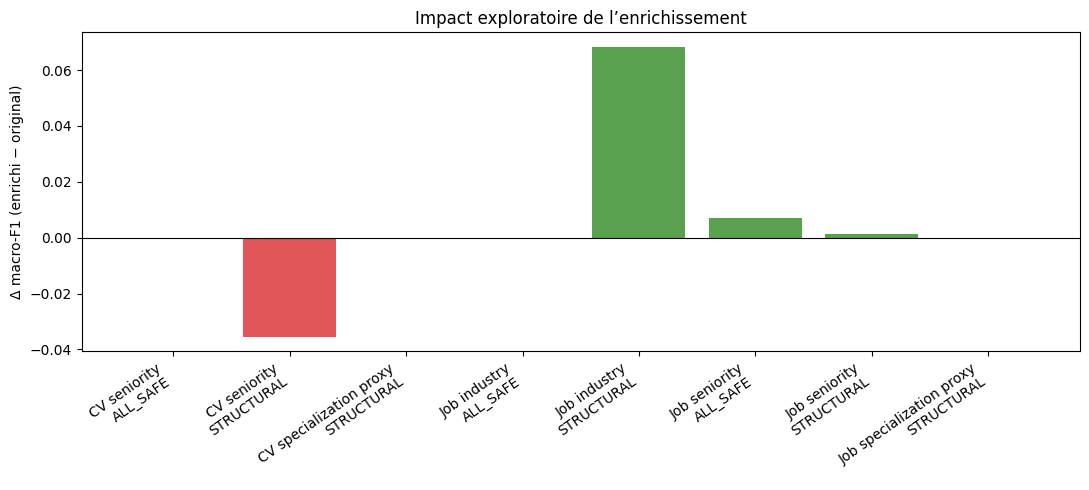

In [8]:
impact=pd.DataFrame(class11['original_vs_enriched_deltas'])
impact.to_csv(RESULTS/'step12_enrichment_classification_impact.csv',index=False)
display(impact)
fig,ax=plt.subplots(figsize=(11,5)); colors=['#59A14F' if x>=0 else '#E15759' for x in impact.delta_macro_f1]
labels=impact.task+'\n'+impact.feature_family
ax.bar(np.arange(len(impact)),impact.delta_macro_f1,color=colors); ax.axhline(0,color='black',lw=.8); ax.set_xticks(np.arange(len(impact)),labels,rotation=35,ha='right'); ax.set_ylabel('Δ macro-F1 (enrichi − original)'); ax.set_title('Impact exploratoire de l’enrichissement')
fig.tight_layout(); fig.savefig(FIGURES/'original_vs_enriched_classification.png',dpi=170,bbox_inches='tight'); plt.show()

## 9. Spécialisation proxy et position dans le graphe

Le proxy `specialized` signifie une seule communauté de skills ; `generalist` plusieurs. Nous
comparons degré, PageRank et communautés sans affirmer de causalité. Une association peut venir du
processus synthétique de génération des matches.

,specialization_label,n,degree_mean,degree_median,pagerank_mean,pagerank_median,community_size_mean,n_skill_communities_mean,entropy_mean,proportion
0,generalist,3159,7.658120,7.0,0.000053,0.000053,1563.798670,2.631529,0.700135,0.3159
1,specialized,6841,7.426984,7.0,0.000052,0.000050,1551.245432,1.000000,0.000000,0.6841


C:\Users\user\AppData\Local\Temp\ipykernel_47380\3583097359.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups,labels=['specialized','generalist'],showfliers=False); axes[0].set_title('Degré original selon le proxy')
C:\Users\user\AppData\Local\Temp\ipykernel_47380\3583097359.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(groups,labels=['specialized','generalist'],showfliers=False); axes[1].set_title('PageRank original selon le proxy')


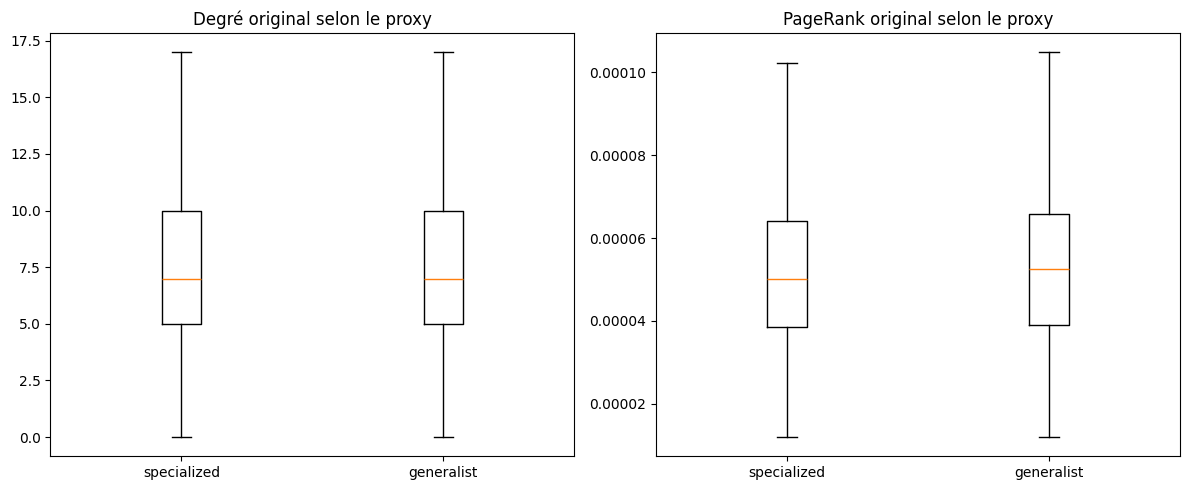

In [9]:
resume_features=pd.read_csv(RESULTS/'step10_resume_features_original.csv',dtype={'resume_id':str})
resume_enriched=pd.read_csv(RESULTS/'step10_resume_features_enriched.csv',dtype={'resume_id':str})
spec_targets=pd.read_csv(RESULTS/'step11_specialization_targets.csv',dtype={'node_id':str})
cv_spec=spec_targets[spec_targets.node_type=='CV'][['node_id','specialization_label']].rename(columns={'node_id':'resume_id'})
cv_analysis=resume_features.merge(cv_spec,on='resume_id',validate='one_to_one')
spec_stats=cv_analysis.groupby('specialization_label').agg(n=('resume_id','size'),degree_mean=('degree','mean'),degree_median=('degree','median'),
 pagerank_mean=('pagerank','mean'),pagerank_median=('pagerank','median'),community_size_mean=('community_size','mean'),
 n_skill_communities_mean=('n_skill_communities','mean'),entropy_mean=('skill_community_entropy','mean')).reset_index()
spec_stats['proportion']=spec_stats.n/spec_stats.n.sum(); display(spec_stats)
fig,axes=plt.subplots(1,2,figsize=(12,5))
groups=[cv_analysis.loc[cv_analysis.specialization_label==x,'degree'] for x in ['specialized','generalist']]
axes[0].boxplot(groups,labels=['specialized','generalist'],showfliers=False); axes[0].set_title('Degré original selon le proxy')
groups=[cv_analysis.loc[cv_analysis.specialization_label==x,'pagerank'] for x in ['specialized','generalist']]
axes[1].boxplot(groups,labels=['specialized','generalist'],showfliers=False); axes[1].set_title('PageRank original selon le proxy')
fig.tight_layout(); fig.savefig(FIGURES/'specialization_graph_position.png',dpi=170,bbox_inches='tight'); plt.show()

## 10. Exemples de CV polyvalents et atypiques

Un CV polyvalent est sélectionné par règle transparente : nombre de communautés de skills maximal,
puis entropie normalisée élevée. « Atypique » est descriptif : degré au-dessus du 95e percentile ou
au-dessous du 5e percentile non nul de sa communauté, ou fort gain de degré après enrichissement.
Aucun modèle complexe d'anomalie n'est introduit et ces profils ne sont ni meilleurs ni moins bons.

In [10]:
def attrs(node):
    d=G_original.nodes[node]; return d.get('role'),d.get('seniority'),d.get('skills')

with (DATA/'cv_job_graph.pkl').open('rb') as f:G_original=pickle.load(f)
poly=cv_analysis.sort_values(['n_skill_communities','skill_community_entropy_normalized','degree'],ascending=False).head(15).copy()
poly[['role','seniority','skills']]=pd.DataFrame([attrs(n) for n in poly.resume_id],index=poly.index)
poly_cols=['resume_id','role','seniority','skills','n_skill_communities','skill_community_entropy','skill_community_entropy_normalized','degree','community_global']
poly[poly_cols].to_csv(RESULTS/'step12_polyvalent_cv_examples.csv',index=False)
display(poly[poly_cols].head(10))

at=cv_analysis.merge(resume_enriched[['resume_id','degree']].rename(columns={'degree':'degree_enriched'}),on='resume_id')
at['degree_delta']=at.degree_enriched-at.degree
q=at.groupby('community_global').degree.quantile([.05,.95]).unstack(); q.columns=['q05','q95']; at=at.join(q,on='community_global')
high=at[at.degree>=at.q95].sort_values('degree',ascending=False).head(6).assign(atypical_reason='high degree within community')
low=at[(at.degree>0)&(at.degree<=at.q05)].sort_values('degree').head(6).assign(atypical_reason='low non-isolated degree within community')
gain=at.sort_values('degree_delta',ascending=False).head(6).assign(atypical_reason='largest enrichment degree gain')
atypical=pd.concat([high,low,gain]).drop_duplicates('resume_id').head(15).copy()
atypical[['role','seniority','skills']]=pd.DataFrame([attrs(n) for n in atypical.resume_id],index=atypical.index)
at_cols=['resume_id','role','seniority','skills','community_global','degree','pagerank','degree_delta','atypical_reason']
atypical[at_cols].to_csv(RESULTS/'step12_atypical_cv_examples.csv',index=False)
display(atypical[at_cols])

,resume_id,role,seniority,skills,n_skill_communities,skill_community_entropy,skill_community_entropy_normalized,degree,community_global
1321,R_001321,Financial Analyst,Senior,"[Reporting, Forecasting, KPIs, Excel, Valuation]",4,1.332179,0.960964,9,1
320,R_000320,Junior Accountant,Junior,"[KPIs, Financial Modeling, Excel, Forecasting,...",4,1.332179,0.960964,8,1
3314,R_003314,FP&A Analyst,Junior,"[Variance Analysis, KPIs, Forecasting, Financi...",4,1.332179,0.960964,8,1
6425,R_006425,Financial Analyst,Junior,"[KPIs, Forecasting, Excel, Financial Modeling,...",4,1.332179,0.960964,8,1
7323,R_007323,FP&A Analyst,Senior,"[Variance Analysis, Excel, Financial Modeling,...",4,1.332179,0.960964,8,1
4666,R_004666,Financial Analyst,Senior,"[KPIs, Forecasting, Accounting, Excel, Valuation]",4,1.332179,0.960964,7,1
4684,R_004684,Junior Accountant,Junior,"[Cash Flow, Excel, Valuation, Reporting, Forec...",4,1.332179,0.960964,7,1
6367,R_006367,Junior Accountant,Mid,"[Valuation, Forecasting, Excel, Reporting, Bud...",4,1.332179,0.960964,7,1
7709,R_007709,Junior Accountant,Junior,"[KPIs, Budgeting, Excel, Variance Analysis, Fo...",4,1.332179,0.960964,7,1
1091,R_001091,Financial Analyst,Mid,"[Forecasting, Variance Analysis, Budgeting, Ex...",4,1.332179,0.960964,6,1


,resume_id,role,seniority,skills,community_global,degree,pagerank,degree_delta,atypical_reason
6412,R_006412,Operations Manager,Mid,"[KPIs, Asana, Timeline Management, Cross-funct...",6,27,0.000151,14,high degree within community
8878,R_008878,Business Development Manager,Junior,"[Pipeline Management, Lead Generation, Outboun...",4,23,0.000135,11,high degree within community
8703,R_008703,Business Development Manager,Mid,"[Outbound Outreach, Forecasting, Account Manag...",4,22,0.000131,5,high degree within community
7153,R_007153,Technical Product Manager,Junior,"[Analytics, User Research, Stakeholder Managem...",2,22,0.000141,8,high degree within community
8358,R_008358,Customer Success Associate,Senior,"[Root Cause Analysis, Zendesk, SLA, Documentat...",7,22,0.000123,13,high degree within community
4339,R_004339,Business Development Manager,Mid,"[Account Management, Forecasting, Discovery Ca...",4,22,0.000130,8,high degree within community
5180,R_005180,Junior Accountant,Junior,"[Excel, Valuation, Budgeting, Forecasting, Acc...",1,1,0.000017,0,low non-isolated degree within community
1764,R_001764,Marketing Manager,Mid,"[Copywriting, Email Marketing, Meta Ads, A/B T...",5,1,0.000018,0,low non-isolated degree within community
7980,R_007980,Product Manager,Mid,"[Roadmap, PRD, Scrum, Product Strategy, Stakeh...",2,1,0.000018,0,low non-isolated degree within community
7973,R_007973,Financial Analyst,Junior,"[Reporting, Budgeting, Forecasting, Cash Flow,...",1,1,0.000018,0,low non-isolated degree within community


## 11. Limites globales

1. Dataset synthétique et matching généré par des règles fortement liées aux skills.
2. ROC-AUC du benchmark 50/50 potentiellement optimiste face au base-rate naturel.
3. Une paire inconnue n'est pas nécessairement un vrai négatif dans le monde réel.
4. CN3/Adamic–Adar sont adaptés au biparti et Katz est tronqué aux marches 3/5.
5. La spécialisation est un pseudo-label, pas une annotation humaine.
6. Les liens enrichis sont des suggestions, pas une ground truth future.
7. Risque indirect de target leakage du graphe enrichi via les textes Step 7.
8. Label Propagation est non déterministe malgré cinq seeds reproductibles.
9. La modularité standard emploie une référence non spécifiquement bipartite.
10. Les performances ne démontrent aucune généralisation sur un marché réel ou temporel.

## 12. Recommandations fondées sur les résultats

- Utiliser Katz tronqué pour générer des candidats structurels et le sémantique comme signal
  complémentaire, sans assimiler le consensus à une preuve de match.
- Préférer une évaluation Top-K/ranking par Job à un seuil global appris sur un benchmark équilibré.
- Conserver `G_original` pour les conclusions principales et `G_enriched` comme scénario exploratoire.
- Exploiter les embeddings safe pour CV seniority et Job industry, tout en validant sur des données
  réelles car la séparation parfaite d'industrie est probablement synthétique.
- Calibrer avec données réelles, temporelles et éventuellement une évaluation cold-start avant tout
  déploiement ; conserver les arêtes predicted séparées des observed.

## 13. Table finale, résumé report-ready et JSON

La table longue uniformise les métriques clés pour le rapport. Le Markdown reprend uniquement ces
valeurs et les summaries validés. Ces artefacts facilitent la rédaction sans inventer de nouveau
résultat.

In [11]:
metric_rows=[]
def add(section,task,method,metric,value): metric_rows.append({'section':section,'task':task,'method':method,'metric':metric,'value':float(value)})
for _,r in lp_test.iterrows():
    for metric in ['roc_auc','average_precision','f1']: add('link_prediction','test',r.method,metric,r[metric])
for _,r in best_models.iterrows():
    add('classification',r.task,f"{r.method} / {r.feature_family} / {r.graph_version}",'test_macro_f1',r.test_macro_f1)
    add('classification',r.task,f"{r.method} / {r.feature_family} / {r.graph_version}",'test_accuracy',r.test_accuracy)
for k,v in [('bipartite_density',struct3['bipartite_density']),('global_modularity',comm4['modularity_networkx']),('skill_modularity',skill5['selected_weighted_modularity']),('community_ARI',features10['community_ARI']),('community_NMI',features10['community_NMI'])]: add('graph','global','observed',k,v)
final_metrics=pd.DataFrame(metric_rows); final_metrics.to_csv(RESULTS/'step12_final_metrics.csv',index=False)

best_lp=lp_test.iloc[0]
report=f'''# Résumé du projet

## Dataset
10 000 CV, 2 500 Jobs et 75 000 couples positifs synthétiques, sans valeurs manquantes ni références invalides.

## Modélisation du graphe
Graphe biparti simple de 12 500 nœuds et 75 000 arêtes observées, densité bipartite {struct3['bipartite_density']:.4f}.

## Analyse structurelle
Degré moyen CV {struct3['average_degree_cv']:.2f}, Job {struct3['average_degree_job']:.2f}; {struct3['n_connected_components']} composantes et {struct3['n_isolates']} CV isolés.

## Communautés
{comm4['n_communities']} communautés globales (Q={comm4['modularity_networkx']:.4f}) et {skill5['n_skill_communities']} communautés de skills (Q pondérée={skill5['selected_weighted_modularity']:.4f}). ARI original/enrichi={features10['community_ARI']:.4f}.

## Prédiction de liens
Meilleure méthode : {best_lp.method}, ROC-AUC test {best_lp.roc_auc:.4f}, AP {best_lp.average_precision:.4f}, F1 {best_lp.f1:.4f} sur benchmark équilibré.

## Enrichissement
Consensus Top-{selected_k} : {compare9['n_predicted_edges_added']} suggestions ajoutées, soit {compare9['n_edges_after']} arêtes. Precision ranking test={compare9['consensus_test_metrics']['consensus_precision']:.5f}; ce ne sont pas de nouveaux labels vrais.

## Classification
''' + '\n'.join(f"- {r.task}: {r.method} / {r.feature_family}, macro-F1 test={r.test_macro_f1:.4f}." for _,r in best_models.iterrows()) + f'''

## Impact de l'enrichissement
Effets faibles ou ambigus selon la tâche ; le graphe original reste la référence à cause du risque indirect de fuite.

## Profils spécialisés / polyvalents
{int((cv_analysis.specialization_label=='specialized').sum())} CV specialized proxy et {int((cv_analysis.specialization_label=='generalist').sum())} generalist proxy ; moyenne {skill5['cv_internal_feature_statistics']['n_skill_communities']['mean']:.3f} communautés de skills.

## Limites
Dataset synthétique, benchmark équilibré optimiste, pseudo-labels, Katz tronqué, modularité standard bipartite, liens prédits sans vérité terrain future et généralisation réelle non démontrée.

## Conclusion
La structure et le texte sont complémentaires, mais le ranking réaliste et les contrôles de fuite imposent une interprétation prudente et une validation future sur données réelles temporelles.
'''
(RESULTS/'step12_report_ready_summary.md').write_text(report,encoding='utf-8')

final_summary={'dataset_summary':audit1,'structural_summary':struct3,'global_community_summary':{'count':comm4['n_communities'],'modularity':comm4['modularity_networkx']},
 'skill_community_summary':{'skills':skill5['n_skill_nodes'],'communities':skill5['n_skill_communities'],'weighted_modularity':skill5['selected_weighted_modularity']},
 'link_prediction_best_method':best_lp.to_dict(),'semantic_vs_structural_summary':compare9['semantic_vs_structural_spearman'],
 'realistic_ranking_summary':{'selected_k':selected_k,'semantic':compare9['semantic_test_ranking_metrics'],'katz':compare9['katz_test_ranking_metrics'],'consensus':compare9['consensus_test_metrics']},
 'enrichment_summary':enrichment_summary.to_dict(),'classification_best_results':best_models.to_dict(orient='records'),
 'classification_feature_family_comparison':family_table.to_dict(orient='records'),'enrichment_classification_effect':impact.to_dict(orient='records'),
 'specialization_summary':spec_stats.to_dict(orient='records'),'atypical_profiles_summary':{'n_examples':len(atypical),'rule':'within-community degree quantiles or enrichment degree gain'},
 'principal_limitations':['synthetic dataset','balanced benchmark base-rate gap','unknown pairs are not certain negatives','truncated/adapted bipartite scores','specialization proxy','predicted edges are not ground truth','indirect target leakage risk','LPA nondeterminism','standard modularity on bipartite graph','real-world generalization unproven'],
 'main_recommendations':['combine structural candidate generation and semantic evidence','evaluate per-job ranking','keep observed and predicted edges separate','validate on real temporal and cold-start data'],
 'models_retrained_in_step12':False,'all_steps_completed':True,'all_assertions_passed':True}
(RESULTS/'step12_final_summary.json').write_text(json.dumps(final_summary,indent=2,ensure_ascii=False,default=float),encoding='utf-8')
print('Artefacts finaux sauvegardés.')

Artefacts finaux sauvegardés.


## 14. Assertions de synthèse

Ces contrôles garantissent qu'aucun modèle n'est réentraîné, que les résultats proviennent des
artefacts existants, que les deux graphes et types d'arêtes restent distingués, et que le proxy de
spécialisation n'est jamais présenté comme causal ou humain.

In [12]:
assert final_summary['models_retrained_in_step12'] is False
assert compare9['n_observed_edges_before']==75_000 and compare9['n_predicted_edges_added']==5_347
assert compare9['n_edges_after']==80_347
assert set(best_models.graph_version)<={'original','invariant'}
assert all('proxy' in x.lower() for x in best_models.task if 'specialization' in x.lower())
assert len(final_metrics)>0 and np.isfinite(final_metrics.value).all()
assert (RESULTS/'step12_report_ready_summary.md').exists()
print('Toutes les assertions passent : aucune métrique inventée, aucun modèle réentraîné.')

Toutes les assertions passent : aucune métrique inventée, aucun modèle réentraîné.


## Conclusion générale

- Le graphe CV–Job est biparti et sparse (`0,3 %` des paires possibles), organisé en plusieurs
  grandes composantes synthétiques et 37 communautés globales très modulaires.
- Huit communautés pondérées de skills ont été détectées. La majorité des CV couvre une seule
  famille ; 6 841 sont `specialized proxy` et 3 159 `generalist proxy`.
- Katz tronqué L=5 gagne la link prediction équilibrée (ROC-AUC test `0,9445`, AP `0,9033`, F1
  `0,9440`). Semantic est complémentaire mais moins performant sur ce benchmark.
- Le ranking réaliste change l'interprétation : à K=50, Precision@K reste proche de `0,3 %` et le
  consensus test atteint seulement `0,358 %` de précision. Une forte AUC ne suffit donc pas pour un
  système de recommandation très sparse.
- L'enrichissement ajoute 5 347 suggestions et porte le graphe à 80 347 arêtes, sans modifier les
  composantes, isolés ou communautés de façon importante (ARI `0,9996`, NMI `0,9994`).
- Pour la classification principale, les embeddings safe prédisent le mieux CV seniority
  (macro-F1 test `0,8769`) et Job industry (`1,0000`, probablement facilité par le synthétique).
  Job seniority demeure faible (`0,2989`). La topologie retrouve fortement les proxies de
  spécialisation CV (`0,9393`) et Job (`0,8982`).
- L'enrichissement n'améliore pas uniformément la classification et présente un risque indirect de
  fuite ; l'original reste la référence. Les profils polyvalents/atypiques produits sont descriptifs,
  jamais des jugements de qualité.
- Les prochaines étapes d'un vrai système seraient une validation temporelle sur données réelles,
  une évaluation cold-start, une calibration du ranking et une validation humaine des suggestions.

**Projet expérimental terminé — Steps 1 à 12.**